# MedBIND3D v17 — Risk-Controlled Residual Modality Adaptation

**Per Prof Cao's detailed revision (all 7 points addressed):**
1. ✅ 5 channels = segmentation channels (BG/NCR/ED/unused/ET), not folds. 5-fold ensemble already averaged by nnU-Net predictor internally. Logits vs probabilities explicitly distinguished throughout.
2. ✅ Spatial residual map r(c, z, y, x) — Mamba2 models cross-slice context, spatial head localizes corrections using TC/ET probability maps as spatial attention.
3. ✅ Exact fallback: g=0 EXACTLY outside tumor candidate region. Hard binary mask. Boundary prior is an additional weighting term inside candidate regions only.
4. ✅ Raw adapted AND safety-clipped outputs reported separately. No claim that floor guarantees Dice improvement.
5. ✅ KL direction changed to KL(teacher || adapted). GT masks are TRAINING-ONLY, never used at inference.
6. ✅ L_risk treated as ablation only. Not in main loss.
7. ✅ 64 train / 16 validation from 80 cached patients. 20 test held out and used only once.

**Ablations (5 conditions):** zero-T1CE baseline → residual only → residual+gate → residual+gate+trust → full model

**Outputs:** `./medbind3d_v17_outputs/` with `v17_` prefix

In [1]:
# ── CELL 1: Setup ──────────────────────────────────────────────────────────────
import numpy as np, pandas as pd, torch, torch.nn as nn
import torch.nn.functional as F, nibabel as nib, cv2
from pathlib import Path
from tqdm import tqdm
from scipy.stats import ttest_rel
from scipy.ndimage import binary_dilation, binary_erosion
import os, warnings, shutil, random, traceback, gc
import matplotlib; matplotlib.use('Agg')
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

os.chdir('C:/Users/arnav/Desktop/MedBIND3D/MedBIND3D/medclipsam/MedCLIP-SAMv2')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

DATA_ROOT  = 'C:/Users/arnav/Desktop/MedBIND3D/MedBIND3D/BraTS2020_training_data/MICCAI_BraTS2020_TrainingData'
CACHE_DIR  = './medbind3d_v14_outputs/prob_cache'   # reuse v14 cache (80 patients)
OUTPUT_DIR = './medbind3d_v17_outputs'
Path(OUTPUT_DIR).mkdir(exist_ok=True)

REGIONS  = ['WT','TC','ET']
N_TEST   = 20
N_CACHED = 80

# ── Training/validation split from 80 cached patients ─────────────────────────
# 64 train / 16 validation — patient-level split, fixed seed
# 20 test patients (indices 0-19 in all_patient_dirs) used ONCE at the end only
random.seed(42)
cached_pids = sorted([d.name for d in Path(CACHE_DIR).iterdir()
                      if d.is_dir() and (d/'gt.npy').exists()
                      and (d/'full_probs.npz').exists()
                      and (d/'zero_probs.npz').exists()])
random.shuffle(cached_pids)
TRAIN_PIDS = cached_pids[:64]
VAL_PIDS   = cached_pids[64:]
print(f'Cached patients: {len(cached_pids)} total  →  {len(TRAIN_PIDS)} train / {len(VAL_PIDS)} val')

def get_test_dirs(root):
    return sorted([d for d in Path(root).iterdir()
                   if d.is_dir() and all(len(list(d.glob(f'*{s}*')))>0
                   for s in ['t1.nii','t1ce.nii','t2.nii','flair.nii','seg.nii'])])[:N_TEST]

test_dirs = get_test_dirs(DATA_ROOT)
print(f'Test patients: {len(test_dirs)} (held out, used ONCE for final eval)')
print(f'Device: {device}')

Cached patients: 80 total  →  64 train / 16 val
Test patients: 20 (held out, used ONCE for final eval)
Device: cuda


In [2]:
# ── CELL 2: Cache Loading + GT Utilities ──────────────────────────────────────

def load_cache(pid):
    """
    Load precomputed nnU-Net outputs for one patient.
    
    IMPORTANT — dimensions clarified (Point 1):
    - The 5 channels in [5, H, W, D] are SEGMENTATION CHANNELS:
        Ch0=Background, Ch1=NCR/NET, Ch2=Edema, Ch3=unused, Ch4=Enhancing Tumor
    - The 5-fold ensemble was already averaged INTERNALLY by nnU-Net predictor.
      We never see individual fold outputs; what we have is the averaged PROBABILITY
      (output of softmax), NOT raw logits.
    - 'full_probs' = probabilities from full-modality run (all 4 MRI sequences)
    - 'zero_probs' = probabilities from zero-T1CE run (T1CE channel set to 0)
    
    Convention used throughout v17:
      probs: output of softmax ∈ [0,1]^5
      logits: log(p/(1-p)) for binary regions, or log(p+ε) for multi-class
    """
    fp = Path(CACHE_DIR)/pid
    full_probs = np.load(str(fp/'full_probs.npz'))['probs']   # [5,H,W,D] float32
    zero_probs = np.load(str(fp/'zero_probs.npz'))['probs']   # [5,H,W,D] float32
    seg        = np.load(str(fp/'gt.npy'))                    # [H,W,D]   int16
    return full_probs, zero_probs, seg

def gt_regions(seg):
    return {'WT':(seg>0).astype(np.float32),
            'TC':((seg==1)|(seg==4)).astype(np.float32),
            'ET':(seg==4).astype(np.float32)}

def region_probs(probs5ch):
    """Convert 5-channel nnU-Net probs to 3 binary-region probabilities."""
    return {
        'WT': np.clip(probs5ch[1]+probs5ch[2]+probs5ch[4], 0, 1),
        'TC': np.clip(probs5ch[1]+probs5ch[4],             0, 1),
        'ET': np.clip(probs5ch[4],                         0, 1),
    }

def dice_3d(pred, gt):
    i=np.sum(pred*gt); u=np.sum(pred)+np.sum(gt)
    return 2.0*i/u if u>0 else 0.0

def hd95(pred, gt):
    """Hausdorff distance 95th percentile (returns NaN if either mask is empty)."""
    from scipy.ndimage import distance_transform_edt
    if pred.sum()==0 or gt.sum()==0: return float('nan')
    dt_pred = distance_transform_edt(~pred.astype(bool))
    dt_gt   = distance_transform_edt(~gt.astype(bool))
    d1 = dt_gt[pred.astype(bool)]
    d2 = dt_pred[gt.astype(bool)]
    return float(np.percentile(np.concatenate([d1,d2]), 95))

# Smoke test
_fp, _zp, _sg = load_cache(TRAIN_PIDS[0])
_rp = region_probs(_zp)
print(f'Cache smoke test: full_probs {_fp.shape}  zero_probs {_zp.shape}  seg {_sg.shape}')
print(f'Channel semantics: BG={_fp[0].mean():.3f} NCR={_fp[1].mean():.3f} '
      f'ED={_fp[2].mean():.3f} (ch3 unused) ET={_fp[4].mean():.3f}')
print(f'Region probs: WT={_rp["WT"].mean():.3f} TC={_rp["TC"].mean():.3f} ET={_rp["ET"].mean():.3f}')
del _fp,_zp,_sg,_rp

Cache smoke test: full_probs (5, 240, 240, 155)  zero_probs (5, 240, 240, 155)  seg (240, 240, 155)
Channel semantics: BG=0.983 NCR=0.001 ED=0.015 (ch3 unused) ET=0.002
Region probs: WT=0.017 TC=0.003 ET=0.002


In [3]:
# ── CELL 3: Token Extraction ──────────────────────────────────────────────────
TOKEN_DIM = 23

def extract_tokens(zero_probs5ch):
    """
    Extract per-slice tokens from zero-T1CE nnU-Net PROBABILITY outputs.
    Returns: [D, TOKEN_DIM] float32
    """
    D = zero_probs5ch.shape[3]
    tokens = []
    for z in range(D):
        sp = zero_probs5ch[:,:,:,z]; feats = []
        # Per-channel stats (5 channels × 3 stats = 15)
        for ch in range(5):
            p = sp[ch]; eps=1e-8
            feats.append(float(p.mean())); feats.append(float(p.max()))
            feats.append(float(-(p*np.log(p+eps)).mean()))
        # Per-region stats (WT/TC/ET × 2 stats = 6)
        for ch_combo in [(1,2,4),(1,4),(4,)]:
            rp = np.clip(sum(sp[c] for c in ch_combo), 0, 1); eps=1e-8
            feats.append(float(rp.mean()))
            feats.append(float(-(rp*np.log(rp+eps)+(1-rp)*np.log(1-rp+eps)).mean()))
        feats.append(z/max(D-1,1))   # z-position
        feats.append(1.0)            # missing T1CE flag
        tokens.append(feats)
    arr = np.array(tokens, dtype=np.float32)
    assert arr.shape == (D, TOKEN_DIM), f'Token shape mismatch: {arr.shape} vs ({D},{TOKEN_DIM})'
    return arr

# Smoke test
_fp, _zp, _sg = load_cache(TRAIN_PIDS[0])
_tok = extract_tokens(_zp)
print(f'Token extraction: {_tok.shape}  (D={_zp.shape[3]}, TOKEN_DIM={TOKEN_DIM})')
del _fp, _zp, _sg, _tok
print('Cell 3 complete')

Token extraction: (155, 23)  (D=155, TOKEN_DIM=23)
Cell 3 complete


In [4]:
# ── CELL 4: Architecture — Spatial Residual Adapter with Exact-Fallback Gate ──

CAND_THRESH = 0.15
TRUST_DELTA = 0.3

class Mamba2Block(nn.Module):
    def __init__(self, d_model=64, d_state=16, d_conv=4, expand=2):
        super().__init__()
        d_inner=int(expand*d_model); dt_rank=max(1,d_model//16)
        self.norm=nn.LayerNorm(d_model); self.in_proj=nn.Linear(d_model,d_inner*2,bias=False)
        self.conv1d=nn.Conv1d(d_inner,d_inner,d_conv,padding=d_conv-1,groups=d_inner,bias=True)
        self.x_proj=nn.Linear(d_inner,dt_rank+d_state*2,bias=False)
        self.dt_proj=nn.Linear(dt_rank,d_inner,bias=True)
        A=torch.arange(1,d_state+1,dtype=torch.float32)
        self.A_log=nn.Parameter(torch.log(A.unsqueeze(0).expand(d_inner,-1)))
        self.D=nn.Parameter(torch.ones(d_inner)); self.out_proj=nn.Linear(d_inner,d_model,bias=False)
    def selective_scan(self,u,dt,A,B,C):
        Bs,L,d=u.shape; s=A.shape[1]
        dA=torch.exp(dt.unsqueeze(-1)*A.unsqueeze(0).unsqueeze(0))
        dB=dt.unsqueeze(-1)*B.unsqueeze(2)
        h=torch.zeros(Bs,d,s,device=u.device,dtype=u.dtype); ys=[]
        for i in range(L):
            h=dA[:,i]*h+dB[:,i]*u[:,i].unsqueeze(-1)
            ys.append((h*C[:,i].unsqueeze(1)).sum(-1))
        return torch.stack(ys,1)+u*self.D
    def forward(self,x):
        B,L,_=x.shape; res=x; x=self.norm(x)
        xz=self.in_proj(x); xi,z=xz.chunk(2,dim=-1)
        xi=F.silu(self.conv1d(xi.transpose(1,2))[:,:,:L].transpose(1,2))
        dtr=self.dt_proj.in_features; xd=self.x_proj(xi)
        dt=F.softplus(self.dt_proj(xd[...,:dtr]))
        B_=xd[...,dtr:dtr+self.A_log.shape[1]]; C=xd[...,dtr+self.A_log.shape[1]:]
        y=self.selective_scan(xi,dt,-torch.exp(self.A_log),B_,C)
        return self.out_proj(y*F.silu(z))+res


class SpatialResidualAdapter(nn.Module):
    def __init__(self, token_dim=23, d_model=64, n_layers=3, n_classes=5):
        super().__init__()
        self.proj   = nn.Sequential(nn.Linear(token_dim,d_model),nn.LayerNorm(d_model),nn.SiLU())
        self.layers = nn.ModuleList([Mamba2Block(d_model) for _ in range(n_layers)])
        self.norm   = nn.LayerNorm(d_model)
        self.corr_head = nn.Linear(d_model, n_classes)
        self.gate_head = nn.Linear(d_model, 1)
        nn.init.zeros_(self.corr_head.weight); nn.init.zeros_(self.corr_head.bias)
        nn.init.zeros_(self.gate_head.weight)
        nn.init.constant_(self.gate_head.bias, -4.0)
    def forward(self, tokens_t):
        x = self.proj(tokens_t)
        for l in self.layers: x = l(x)
        x = self.norm(x)
        corr       = torch.tanh(self.corr_head(x[0])) * TRUST_DELTA   # [D,5]
        gate_logit = self.gate_head(x[0])                             # [D,1]
        return corr, gate_logit


def apply_spatial_residual(zero_probs_np, corr_t, gate_logit_t,
                            cand_thresh=CAND_THRESH, use_gate=True,
                            use_trust=True, boundary_weight=2.0):
    """
    DIFFERENTIABLE — returns adapted_probs_raw_t as a tensor WITH grad_fn.
    Also returns numpy arrays for evaluation (no grad).

    Point 3: Outside candidate mask, gate=0 EXACTLY → output=zero_T1CE EXACTLY.
    Point 4: Returns raw AND clipped separately.
    """
    H,W,D = zero_probs_np.shape[1],zero_probs_np.shape[2],zero_probs_np.shape[3]
    dev = corr_t.device

    p0 = np.clip(zero_probs_np, 1e-6, 1-1e-6)
    zero_logits_t = torch.FloatTensor(np.log(p0/(1-p0))).to(dev)   # [5,H,W,D] no grad needed

    # Candidate mask — hard binary, numpy → tensor (no grad)
    tc_prob = np.clip(zero_probs_np[1]+zero_probs_np[4], 0, 1)
    et_prob = np.clip(zero_probs_np[4], 0, 1)
    M_cand  = torch.FloatTensor(
        ((tc_prob>cand_thresh)|(et_prob>cand_thresh)).astype(np.float32)).to(dev)  # [H,W,D]

    # Boundary weighting (inside candidate only — additional term, not gating criterion)
    et_mask = (et_prob>0.5)
    boundary = np.zeros((H,W,D), dtype=np.float32)
    if et_mask.sum()>10:
        et_dil = binary_dilation(et_mask, iterations=3)
        et_ero = binary_erosion(et_mask, iterations=1) if et_mask.sum()>50 else np.zeros_like(et_mask)
        boundary = (et_dil & ~et_ero).astype(np.float32)
    bdry_w = torch.FloatTensor(1.0+(boundary_weight-1.0)*boundary).to(dev)   # [H,W,D]

    # Spatial attention from TC/ET probs — where to concentrate correction
    cand_np = ((tc_prob>cand_thresh)|(et_prob>cand_thresh)).astype(np.float32)
    spattn_np = (tc_prob+et_prob)*cand_np
    cand_count = cand_np.sum(axis=(0,1), keepdims=True)+1e-8
    cand_sum   = spattn_np.sum(axis=(0,1), keepdims=True)+1e-8
    spattn_np  = spattn_np / (cand_sum/cand_count)
    spattn_t   = torch.FloatTensor(spattn_np).to(dev)   # [H,W,D]

    # Gate [H,W,D] — differentiable via gate_logit_t, hard-zeroed outside candidate
    if use_gate:
        gate_slice = torch.sigmoid(gate_logit_t[:,0])              # [D] has grad
        gate_3d    = gate_slice.view(1,1,D) * bdry_w * M_cand     # [H,W,D]
    else:
        gate_3d = M_cand   # gate=1 everywhere in candidate, 0 outside

    # Spatial residual r(c,z,y,x) = corr[z,c] * spattn[y,x,z] — DIFFERENTIABLE
    # corr_t: [D,5] has grad;  spattn_t: [H,W,D] no grad
    adapted_logits_t = zero_logits_t.clone()
    for c in range(5):
        r_c       = corr_t[:, c].view(1,1,D)            # [1,1,D] has grad
        r_spatial = r_c * spattn_t                       # [H,W,D] has grad
        adapted_logits_t[c] = zero_logits_t[c] + gate_3d * r_spatial  # [H,W,D]

    adapted_probs_raw_t = torch.sigmoid(adapted_logits_t)   # [5,H,W,D] HAS GRAD

    # Numpy outputs for evaluation (detached — no grad)
    with torch.no_grad():
        probs_raw_np  = adapted_probs_raw_t.detach().cpu().numpy()
        probs_clip_np = np.maximum(probs_raw_np, p0 - 0.02)
        gate_map_np   = gate_3d.detach().cpu().numpy()

    return adapted_probs_raw_t, probs_raw_np, probs_clip_np, gate_map_np


def probs_to_preds(probs_np, thresh=0.5):
    return {'WT':((probs_np[1]+probs_np[2]+probs_np[4])>thresh).astype(float),
            'TC':((probs_np[1]+probs_np[4])>thresh).astype(float),
            'ET':(probs_np[4]>thresh).astype(float)}


# Initialize adapter
adapter = SpatialResidualAdapter(token_dim=TOKEN_DIM, d_model=64, n_layers=3).to(device)
print(f'SpatialResidualAdapter: {sum(p.numel() for p in adapter.parameters())/1e3:.1f}K params')

# Smoke test
_fp,_zp,_sg = load_cache(TRAIN_PIDS[0])
_tok_t = torch.FloatTensor(extract_tokens(_zp)).unsqueeze(0).to(device)
_corr,_gate_logit = adapter(_tok_t)
assert _corr.shape==(_zp.shape[3],5)
assert _corr.abs().max().item()<=TRUST_DELTA+0.01

# Test differentiability
_probs_raw_t, _probs_raw_np, _probs_clip_np, _gate_map = apply_spatial_residual(_zp,_corr,_gate_logit)
assert _probs_raw_t.requires_grad, 'FAILED: probs_raw_t has no grad_fn!'
_gtr = gt_regions(_sg)
_ada_rp = torch.clamp(_probs_raw_t[4], 1e-6, 1-1e-6)
_gt_t   = torch.FloatTensor(_gtr['ET']).to(device)
_loss   = 1 - (2*(_ada_rp.reshape(-1)*_gt_t.reshape(-1)).sum()+1) / (_ada_rp.reshape(-1).sum()+_gt_t.reshape(-1).sum()+1)
_loss.backward()
print(f'SMOKE TEST PASSED: probs_raw_t has grad={_probs_raw_t.requires_grad}')
print(f'Initial gate mean={torch.sigmoid(_gate_logit).mean().item():.4f} (should be near 0)')
print(f'Gate=0 outside candidate: {(_gate_map[~((np.clip(_zp[1]+_zp[4],0,1)>CAND_THRESH)|(np.clip(_zp[4],0,1)>CAND_THRESH))]).max()<1e-6}')
del _fp,_zp,_sg,_tok_t,_corr,_gate_logit,_probs_raw_t,_probs_raw_np,_probs_clip_np,_gate_map,_gtr,_ada_rp,_gt_t,_loss
gc.collect(); torch.cuda.empty_cache()

SpatialResidualAdapter: 100.5K params
SMOKE TEST PASSED: probs_raw_t has grad=True
Initial gate mean=0.0180 (should be near 0)
Gate=0 outside candidate: True


In [5]:
# ── CELL 5: EXACT-FALLBACK SANITY CHECKS + PILOT ─────────────────────────────
print('='*70); print('EXACT-FALLBACK SANITY CHECKS'); print('='*70)

n_checked=0; all_passed=True
for pid in TRAIN_PIDS[:10]:
    fp,zp,sg=load_cache(pid)
    tok_t=torch.FloatTensor(extract_tokens(zp)).unsqueeze(0).to(device)
    with torch.no_grad(): corr,gate_logit=adapter(tok_t)
    _,probs_raw_np,_,gate_map=apply_spatial_residual(zp,corr,gate_logit)
    tc_prob=np.clip(zp[1]+zp[4],0,1); et_prob=np.clip(zp[4],0,1)
    outside=~((tc_prob>CAND_THRESH)|(et_prob>CAND_THRESH))
    if outside.sum()>0:
        md=np.abs(probs_raw_np[:,outside]-np.clip(zp,1e-6,1-1e-6)[:,outside]).max()
        if md<1e-4: print(f'  {pid}: ✓ Exact fallback OK (max_diff={md:.2e})')
        else: print(f'  {pid}: ✗ FAILED (max_diff={md:.4f})'); all_passed=False
    if len(gate_map[outside])>0 and gate_map[outside].max()>=1e-6:
        print(f'  {pid}: ✗ FAILED gate≠0 outside'); all_passed=False
    n_checked+=1
    del fp,zp,sg,tok_t,corr,gate_logit,probs_raw_np,gate_map; gc.collect()

print(f'\nChecked {n_checked}. Result: {"ALL PASSED" if all_passed else "SOME FAILED"}')

def soft_dice(pred, target, smooth=1.0):
    i=(pred*target).sum(); u=pred.sum()+target.sum()
    return 1-(2*i+smooth)/(u+smooth)

print('\nRunning pilot (3 epochs, 10 patients)...')
pilot_adapter=SpatialResidualAdapter(token_dim=TOKEN_DIM,d_model=64,n_layers=3).to(device)
pilot_opt=torch.optim.Adam(pilot_adapter.parameters(),lr=5e-4)
pilot_losses=[]
for ep in range(3):
    ep_loss=0.0; n=0
    for pid in TRAIN_PIDS[:10]:
        try:
            fp,zp,sg=load_cache(pid); gtr=gt_regions(sg)
            tok_t=torch.FloatTensor(extract_tokens(zp)).unsqueeze(0).to(device)
            pilot_opt.zero_grad(); corr,gate_logit=pilot_adapter(tok_t)
            probs_raw_t,_,_,_=apply_spatial_residual(zp,corr,gate_logit)
            loss=0.0
            for r,combo in zip(REGIONS,[(1,2,4),(1,4),(4,)]):
                ada_rp=torch.clamp(sum(probs_raw_t[c] for c in combo),1e-6,1-1e-6)
                loss+=soft_dice(ada_rp.reshape(-1),torch.FloatTensor(gtr[r]).reshape(-1).to(device))
            (loss/3).backward(); pilot_opt.step()
            ep_loss+=loss.item()/3; n+=1
            del fp,zp,sg,gtr,tok_t,corr,gate_logit,probs_raw_t
        except Exception as e: print(f'  [FAILED] {pid}: {e}'); traceback.print_exc()
    pilot_losses.append(ep_loss/max(n,1))
    print(f'  Pilot epoch {ep+1}/3  Loss: {pilot_losses[-1]:.4f}')

assert pilot_losses[-1]<pilot_losses[0],'PILOT FAILED'
print('PILOT PASSED — proceed to Cell 6')
del pilot_adapter,pilot_opt

EXACT-FALLBACK SANITY CHECKS
  BraTS20_Training_243: ✓ Exact fallback OK (max_diff=5.96e-08)
  BraTS20_Training_296: ✓ Exact fallback OK (max_diff=5.96e-08)
  BraTS20_Training_109: ✓ Exact fallback OK (max_diff=5.96e-08)
  BraTS20_Training_246: ✓ Exact fallback OK (max_diff=5.96e-08)
  BraTS20_Training_142: ✓ Exact fallback OK (max_diff=5.96e-08)
  BraTS20_Training_267: ✓ Exact fallback OK (max_diff=5.96e-08)
  BraTS20_Training_051: ✓ Exact fallback OK (max_diff=5.96e-08)
  BraTS20_Training_223: ✓ Exact fallback OK (max_diff=5.96e-08)
  BraTS20_Training_284: ✓ Exact fallback OK (max_diff=5.96e-08)
  BraTS20_Training_192: ✓ Exact fallback OK (max_diff=5.96e-08)

Checked 10. Result: ALL PASSED

Running pilot (3 epochs, 10 patients)...
  Pilot epoch 1/3  Loss: 0.2485
  Pilot epoch 2/3  Loss: 0.2484
  Pilot epoch 3/3  Loss: 0.2483
PILOT PASSED — proceed to Cell 6


In [6]:
# ── CELL 6: LOSS FUNCTIONS ─────────────────────────────────────────────────────

def et_boundary_loss(pred_et, gt_et, boundary_weight=5.0):
    gt_np=gt_et.cpu().numpy().astype(bool)
    if gt_np.sum()<10:
        return F.binary_cross_entropy(pred_et.reshape(-1),gt_et.reshape(-1),reduction='mean')
    dil=binary_dilation(gt_np,iterations=2)
    ero=binary_erosion(gt_np,iterations=2) if gt_np.sum()>50 else np.zeros_like(gt_np)
    w=torch.FloatTensor(1.0+(boundary_weight-1.0)*(dil&~ero).astype(np.float32)).to(pred_et.device)
    bce=F.binary_cross_entropy(pred_et.reshape(-1),gt_et.reshape(-1),reduction='none')
    return (bce*w.reshape(-1)).mean()

def kl_teacher_adapted(full_probs_np, adapted_probs_t, tumor_mask_np):
    """KL(teacher || adapted) inside tumor mask only. Mask is TRAINING-ONLY GT."""
    if tumor_mask_np.sum()<10: return torch.tensor(0.,device=adapted_probs_t.device)
    mask_t=torch.BoolTensor(tumor_mask_np.astype(bool)).to(adapted_probs_t.device)
    loss=torch.tensor(0.,device=adapted_probs_t.device)
    for c in range(5):
        tp=torch.FloatTensor(np.clip(full_probs_np[c][tumor_mask_np.astype(bool)],1e-6,1-1e-6)).to(adapted_probs_t.device)
        ap=adapted_probs_t[c][mask_t].clamp(1e-6,1-1e-6)
        loss+=(tp*(torch.log(tp)-torch.log(ap))).mean()
    return loss/5

print('Loss functions ready')
print('KL direction: KL(teacher || adapted) — GT masks TRAINING-ONLY, never at inference')

Loss functions ready
KL direction: KL(teacher || adapted) — GT masks TRAINING-ONLY, never at inference


In [13]:
# ── CELL 7: TRAIN ALL 4 ABLATION CONDITIONS ───────────────────────────────────
N_EPOCHS=30; LR=5e-4

ABLATION_CONFIGS={
    'B_residual_only':       {'use_gate':False,'use_trust':False,'use_distil':False,'use_boundary':False,'lambda_identity':0.0},
    'C_residual_gate':       {'use_gate':True, 'use_trust':False,'use_distil':False,'use_boundary':False,'lambda_identity':0.0},
    'D_residual_gate_trust': {'use_gate':True, 'use_trust':True, 'use_distil':False,'use_boundary':False,'lambda_identity':1.0},
    'E_full':                {'use_gate':True, 'use_trust':True, 'use_distil':True, 'use_boundary':True, 'lambda_identity':1.0},
}
trained_adapters={}

for ablation_name,cfg in ABLATION_CONFIGS.items():
    print(f'\n{"="*60}\nTraining: {ablation_name}\n{"="*60}')
    abl_adapter=SpatialResidualAdapter(token_dim=TOKEN_DIM,d_model=64,n_layers=3).to(device)
    optimizer=torch.optim.Adam(abl_adapter.parameters(),lr=LR,weight_decay=1e-4)
    scheduler=torch.optim.lr_scheduler.CosineAnnealingLR(optimizer,N_EPOCHS)
    abl_adapter.train(); best_val_dice=-1.0; best_state=None

    for epoch in range(N_EPOCHS):
        ep_loss=0.0; n_steps=0
        random.shuffle(TRAIN_PIDS)
        for pid in tqdm(TRAIN_PIDS,desc=f'Epoch {epoch+1}/{N_EPOCHS}',leave=False):
            try:
                fp,zp,sg=load_cache(pid); gtr=gt_regions(sg)
                tc_gt=(sg==1)|(sg==4); et_gt=(sg==4)
                et_dil=binary_dilation(et_gt,iterations=3) if et_gt.sum()>0 else et_gt
                tumor_mask=(tc_gt|et_dil).astype(np.float32)

                tok_t=torch.FloatTensor(extract_tokens(zp)).unsqueeze(0).to(device)
                optimizer.zero_grad(); corr,gate_logit=abl_adapter(tok_t)
                probs_raw_t,_,_,_=apply_spatial_residual(zp,corr,gate_logit,
                                                          use_gate=cfg['use_gate'],
                                                          use_trust=cfg['use_trust'])

                seg_loss=0.0
                for r,w,combo in zip(REGIONS,[1.,2.,3.],[(1,2,4),(1,4),(4,)]):
                    ada_rp=torch.clamp(sum(probs_raw_t[c] for c in combo),1e-6,1-1e-6)
                    seg_loss+=w*soft_dice(ada_rp.reshape(-1),torch.FloatTensor(gtr[r]).reshape(-1).to(device))
                seg_loss/=6.0

                id_loss=torch.tensor(0.,device=device)
                if cfg['lambda_identity']>0:
                    p0_t=torch.FloatTensor(np.clip(zp,1e-6,1-1e-6)).to(device)
                    inside=((np.clip(zp[1]+zp[4],0,1)>CAND_THRESH)|(np.clip(zp[4],0,1)>CAND_THRESH)).astype(np.float32)
                    w_id=torch.FloatTensor(1.0*inside+3.0*(1-inside)).to(device)
                    id_loss=(torch.abs(probs_raw_t-p0_t)*w_id.unsqueeze(0)).mean()

                trust_loss=torch.abs(corr).mean() if cfg['use_trust'] else torch.tensor(0.,device=device)
                distil_loss=kl_teacher_adapted(fp,probs_raw_t,tumor_mask) if cfg['use_distil'] else torch.tensor(0.,device=device)

                bdry_loss=torch.tensor(0.,device=device)
                if cfg['use_boundary']:
                    gt_np=gtr['ET'].astype(bool)
                    if gt_np.sum()>10:
                        dil=binary_dilation(gt_np,iterations=2)
                        ero=binary_erosion(gt_np,iterations=2) if gt_np.sum()>50 else np.zeros_like(gt_np)
                        bdry_w=torch.FloatTensor(1.0+4.0*(dil&~ero).astype(np.float32)).to(device)
                        bce=F.binary_cross_entropy(torch.clamp(probs_raw_t[4],1e-6,1-1e-6).reshape(-1),
                                                   torch.FloatTensor(gtr['ET']).reshape(-1).to(device),reduction='none')
                        bdry_loss=(bce*bdry_w.reshape(-1)).mean()

                loss=seg_loss+cfg['lambda_identity']*id_loss+0.3*trust_loss+0.5*distil_loss+1.5*bdry_loss
                loss.backward()
                torch.nn.utils.clip_grad_norm_(abl_adapter.parameters(),1.0)
                optimizer.step(); ep_loss+=loss.item(); n_steps+=1
                del fp,zp,sg,gtr,tok_t,corr,gate_logit,probs_raw_t
            except Exception as e:
                print(f'  [FAILED] {pid}: {e}'); traceback.print_exc(); continue

        scheduler.step()
        if n_steps==0: raise RuntimeError(f'Epoch {epoch+1}: zero steps.')

        if (epoch+1)%5==0 or epoch==N_EPOCHS-1:
            abl_adapter.eval(); val_dices=[]
            for pid in VAL_PIDS:
                try:
                    _,zp_v,sg_v=load_cache(pid); gtr_v=gt_regions(sg_v)
                    tok_v=torch.FloatTensor(extract_tokens(zp_v)).unsqueeze(0).to(device)
                    with torch.no_grad(): corr_v,gate_v=abl_adapter(tok_v)
                    _,probs_v,_,_=apply_spatial_residual(zp_v,corr_v,gate_v,
                                                         use_gate=cfg['use_gate'],use_trust=cfg['use_trust'])
                    preds_v=probs_to_preds(probs_v)
                    val_dices.append(np.mean([dice_3d(preds_v[r],gtr_v[r]) for r in REGIONS]))
                    del zp_v,sg_v,gtr_v,tok_v,corr_v,gate_v,probs_v,preds_v
                except: continue
            val_dice=np.mean(val_dices) if val_dices else 0
            if val_dice>best_val_dice:
                best_val_dice=val_dice
                best_state={k:v.clone() for k,v in abl_adapter.state_dict().items()}
            print(f'  Epoch {epoch+1:2d}/{N_EPOCHS}  Loss:{ep_loss/n_steps:.4f}  '
                  f'Val:{val_dice:.4f}  Best:{best_val_dice:.4f}')
            abl_adapter.train()
        gc.collect(); torch.cuda.empty_cache()

    if best_state: abl_adapter.load_state_dict(best_state)
    torch.save(abl_adapter.state_dict(),f'{OUTPUT_DIR}/v17_{ablation_name}.pth')
    trained_adapters[ablation_name]=abl_adapter
    print(f'Saved: v17_{ablation_name}.pth  (best val Dice: {best_val_dice:.4f})')

print('\nAll ablation adapters trained.')


Training: B_residual_only


  Epoch  5/30  Loss:0.3197  Val:0.7450  Best:0.7450


  Epoch 10/30  Loss:0.3196  Val:0.7450  Best:0.7450


  Epoch 15/30  Loss:0.3196  Val:0.7450  Best:0.7450


  Epoch 20/30  Loss:0.3196  Val:0.7450  Best:0.7450


...

  [FAILED] BraTS20_Training_105: Unable to allocate 170. MiB for an array with shape (5, 240, 240, 155) and data type float32


Epoch 23/30:  55%|█████▍    | 35/64 [01:35<01:14,  2.58s/it]Traceback (most recent call last):
  File "C:\Users\arnav\AppData\Local\Temp\ipykernel_197256\3117474022.py", line 24, in <module>
    fp,zp,sg=load_cache(pid); gtr=gt_regions(sg)
             ^^^^^^^^^^^^^^^
  File "C:\Users\arnav\AppData\Local\Temp\ipykernel_197256\721269539.py", line 23, in load_cache
    seg        = np.load(str(fp/'gt.npy'))                    # [H,W,D]   int16
                 ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\arnav\Desktop\MedBIND3D\venv\Lib\site-packages\numpy\lib\_npyio_impl.py", line 483, in load
    return format.read_array(fid, allow_pickle=allow_pickle,
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\arnav\Desktop\MedBIND3D\venv\Lib\site-packages\numpy\lib\_format_impl.py", line 847, in read_array
    array = numpy.fromfile(fp, dtype=dtype, count=count)
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
numpy._core._exceptions._ArrayMemoryError: Unable 

  [FAILED] BraTS20_Training_307: Unable to allocate 17.0 MiB for an array with shape (8928000,) and data type int16


  Epoch 25/30  Loss:0.4271  Val:0.7427  Best:0.7427


  Epoch 30/30  Loss:0.4271  Val:0.7427  Best:0.7427
Saved: v17_E_full.pth  (best val Dice: 0.7427)

All ablation adapters trained.


In [8]:
# ── Load trained adapters from checkpoints ─────────────────────────────────────
ABLATION_CONFIGS = {
    'B_residual_only':       {'use_gate':False,'use_trust':False,'use_distil':False,'use_boundary':False,'lambda_identity':0.0},
    'C_residual_gate':       {'use_gate':True, 'use_trust':False,'use_distil':False,'use_boundary':False,'lambda_identity':0.0},
    'D_residual_gate_trust': {'use_gate':True, 'use_trust':True, 'use_distil':False,'use_boundary':False,'lambda_identity':1.0},
    'E_full':                {'use_gate':True, 'use_trust':True, 'use_distil':True, 'use_boundary':True, 'lambda_identity':1.0},
}

trained_adapters = {}
for ablation_name in ABLATION_CONFIGS:
    ckpt = f'{OUTPUT_DIR}/v17_{ablation_name}.pth'
    assert Path(ckpt).exists(), f'Checkpoint not found: {ckpt}'
    abl_adapter = SpatialResidualAdapter(token_dim=TOKEN_DIM, d_model=64, n_layers=3).to(device)
    abl_adapter.load_state_dict(torch.load(ckpt, map_location=device))
    abl_adapter.eval()
    trained_adapters[ablation_name] = abl_adapter
    print(f'Loaded: {ablation_name}')

print(f'\nAll {len(trained_adapters)} adapters loaded from checkpoints')

Loaded: B_residual_only
Loaded: C_residual_gate
Loaded: D_residual_gate_trust
Loaded: E_full

All 4 adapters loaded from checkpoints


In [9]:
# ── CELL 8: FULL EVALUATION ON TEST SET (used ONCE) ──────────────────────────
# Point 4: Report raw adapted AND safety-clipped outputs separately
# Metrics: Dice, HD95, feature distance (6 regions), fallback rate, improvement/degradation fraction

def logit_dist_region(p1, p2, mask):
    if mask.sum()<5: return float('nan')
    p1c=np.clip(p1,1e-6,1-1e-6); p2c=np.clip(p2,1e-6,1-1e-6)
    l1=np.log(p1c/(1-p1c)); l2=np.log(p2c/(1-p2c))
    diff_sq=((l1[[1,4]]-l2[[1,4]])**2).mean(axis=0)
    return float(np.sqrt(diff_sq[mask].mean()))

def load_test_patient(pd_):
    vols = np.stack([
        nib.load(str(list(pd_.glob(f'*{m}.nii*'))[0])).get_fdata(dtype=np.float32)
        for m in ['flair','t1','t1ce','t2']], axis=0)
    for i in range(4):
        mask=vols[i]>0
        if mask.sum()>0: vols[i][mask]=(vols[i][mask]-vols[i][mask].mean())/(vols[i][mask].std()+1e-8)
    seg = nib.load(str(list(pd_.glob('*seg.nii*'))[0])).get_fdata().astype(np.int16)
    return vols, seg

from nnunetv2.inference.predict_from_raw_data import nnUNetPredictor
model_folder = './nnunet_results/Dataset002_BRATS19/nnUNetTrainer__nnUNetPlans__3d_fullres'
predictor = nnUNetPredictor(
    tile_step_size=0.5, use_gaussian=True, use_mirroring=True,
    perform_everything_on_device=True, device=device, verbose=False, allow_tqdm=False)
predictor.initialize_from_trained_model_folder(
    model_folder, use_folds=(0,1,2,3,4), checkpoint_name='checkpoint_final.pth')
print('nnU-Net loaded for test evaluation')

all_conditions = ['A_zero_baseline'] + list(trained_adapters.keys())
eval_rows = []

for pd_ in tqdm(test_dirs, desc='Test patients'):
    pid = pd_.name
    try:
        vols, seg = load_test_patient(pd_)
        gtr = gt_regions(seg)

        # nnU-Net zero-T1CE prediction
        inp_zero = np.stack([vols[0], vols[1], np.zeros_like(vols[2]), vols[3]], axis=0)
        res_zero = predictor.predict_single_npy_array(inp_zero, {'spacing':[1.0,1.0,1.0]}, None, None, True)
        zp = res_zero[1] if isinstance(res_zero,tuple) else res_zero  # [5,H,W,D] probs

        # nnU-Net full-modality (for feature distance computation)
        res_full = predictor.predict_single_npy_array(vols.copy(), {'spacing':[1.0,1.0,1.0]}, None, None, True)
        fp = res_full[1] if isinstance(res_full,tuple) else res_full

        row = {'Patient': pid}
        base_preds = probs_to_preds(zp)

        # Region masks for distance computation
        wt_mask=(seg>0); tc_mask=(seg==1)|(seg==4); et_mask=(seg==4); bg_mask=(seg==0)
        et_dil=binary_dilation(et_mask,iterations=3) if et_mask.sum()>0 else et_mask
        et_ero=binary_erosion(et_mask,iterations=1) if et_mask.sum()>50 else np.zeros_like(et_mask)
        et_bdry=(et_dil&~et_ero)

        # ── Condition A: zero-T1CE baseline ──────────────────────────────────
        for r in REGIONS:
            row[f'A_Dice_{r}'] = dice_3d(base_preds[r], gtr[r])
            if et_mask.sum()>10:
                row[f'A_HD95_{r}'] = hd95(base_preds[r].astype(bool), gtr[r].astype(bool))
        for rname, mask in [('whole',np.ones_like(seg,dtype=bool)),('WT',wt_mask),('TC',tc_mask),
                             ('ET',et_mask),('ET_bdry',et_bdry),('BG',bg_mask)]:
            row[f'A_FeatDist_{rname}'] = logit_dist_region(fp, zp, mask)

        # ── Conditions B-E: ablation adapters ────────────────────────────────
        tok = extract_tokens(zp)
        tok_t = torch.FloatTensor(tok).unsqueeze(0).to(device)

        for abl_name, abl_adapter in trained_adapters.items():
            cfg = ABLATION_CONFIGS[abl_name]
            abl_adapter.eval()
            with torch.no_grad():
                corr, gate_logit = abl_adapter(tok_t)
            _, probs_raw, probs_clip, gate_map = apply_spatial_residual(
                zp, corr, gate_logit,
                use_gate=cfg['use_gate'], use_trust=cfg['use_trust'])

            preds_raw  = probs_to_preds(probs_raw)
            preds_clip = probs_to_preds(probs_clip)

            for r in REGIONS:
                # Raw adapted (Point 4)
                row[f'{abl_name}_Dice_{r}_raw']  = dice_3d(preds_raw[r], gtr[r])
                row[f'{abl_name}_Dice_{r}_clip'] = dice_3d(preds_clip[r], gtr[r])
                if et_mask.sum()>10:
                    row[f'{abl_name}_HD95_{r}_raw'] = hd95(preds_raw[r].astype(bool), gtr[r].astype(bool))
                # Improved / degraded vs baseline
                delta = row[f'{abl_name}_Dice_{r}_raw'] - row[f'A_Dice_{r}']
                row[f'{abl_name}_Delta_{r}'] = delta

            # Feature distances
            for rname, mask in [('whole',np.ones_like(seg,dtype=bool)),('WT',wt_mask),('TC',tc_mask),
                                 ('ET',et_mask),('ET_bdry',et_bdry),('BG',bg_mask)]:
                row[f'{abl_name}_FeatDist_{rname}'] = logit_dist_region(fp, probs_raw, mask)

            # Fallback rate: fraction of voxels where gate < 0.05 (adapter defers to baseline)
            row[f'{abl_name}_FallbackRate'] = float((gate_map < 0.05).mean())
            del corr, gate_logit, probs_raw, probs_clip, gate_map

        eval_rows.append(row)
        pd.DataFrame(eval_rows).to_csv(f'{OUTPUT_DIR}/v17_test_results.csv', index=False)
        print(f'  {pid}: A_ET={row["A_Dice_ET"]:.3f}  '
              f'E_ET_raw={row.get("E_full_Dice_ET_raw",float("nan")):.3f}')
        del vols,seg,gtr,zp,fp,base_preds,tok,tok_t
        gc.collect(); torch.cuda.empty_cache()
    except Exception as e:
        print(f'  [FAILED] {pid}: {e}'); traceback.print_exc()

print(f'\nTest evaluation complete: {len(eval_rows)} patients')

nnU-Net loaded for test evaluation


Test patients:   0%|          | 0/20 [00:00<?, ?it/s]

  BraTS20_Training_001: A_ET=0.681  E_ET_raw=0.681


Test patients:  10%|█         | 2/20 [03:30<31:24, 104.72s/it]

  BraTS20_Training_002: A_ET=0.768  E_ET_raw=0.768


...

  BraTS20_Training_018: A_ET=0.495  E_ET_raw=0.495


Test patients:  95%|█████████▌| 19/20 [31:24<01:39, 99.47s/it]

  BraTS20_Training_019: A_ET=0.614  E_ET_raw=0.614


Test patients: 100%|██████████| 20/20 [33:05<00:00, 99.30s/it]

  BraTS20_Training_020: A_ET=0.386  E_ET_raw=0.386

Test evaluation complete: 20 patients


In [10]:
# ── CELL 9: ANALYSIS — All Metrics + Risk-Coverage Curves ────────────────────
df = pd.read_csv(f'{OUTPUT_DIR}/v17_test_results.csv')

print('='*80)
print('MedBIND3D v17 — Risk-Controlled Residual Modality Adaptation')
print('ABLATION COMPARISON (20 test patients, missing T1CE scenario)')
print('='*80)

abl_labels = {'A_zero_baseline':'A: Zero-T1CE Baseline',
              'B_residual_only':'B: Residual Only',
              'C_residual_gate':'C: Residual + Gate',
              'D_residual_gate_trust':'D: + Trust Region',
              'E_full':'E: Full Model (main)'}

print(f'\n{"Condition":<30}{"WT Dice":<12}{"TC Dice":<12}{"ET Dice":<12}{"ET HD95"}')
print('-'*75)

for abl_key, abl_label in abl_labels.items():
    if abl_key == 'A_zero_baseline':
        wt=df['A_Dice_WT'].mean(); tc=df['A_Dice_TC'].mean(); et=df['A_Dice_ET'].mean()
        hd=df['A_HD95_ET'].mean() if 'A_HD95_ET' in df.columns else float('nan')
        print(f'{abl_label:<30}{wt:.4f}      {tc:.4f}      {et:.4f}      {hd:.2f}')
    else:
        wt=df[f'{abl_key}_Dice_WT_raw'].mean()
        tc=df[f'{abl_key}_Dice_TC_raw'].mean()
        et=df[f'{abl_key}_Dice_ET_raw'].mean()
        hd=df[f'{abl_key}_HD95_ET_raw'].mean() if f'{abl_key}_HD95_ET_raw' in df.columns else float('nan')
        wt_clip=df[f'{abl_key}_Dice_WT_clip'].mean()
        tc_clip=df[f'{abl_key}_Dice_TC_clip'].mean()
        et_clip=df[f'{abl_key}_Dice_ET_clip'].mean()
        fr=df[f'{abl_key}_FallbackRate'].mean()
        print(f'{abl_label:<30}{wt:.4f}      {tc:.4f}      {et:.4f}      {hd:.2f}')
        print(f'  (clipped: WT={wt_clip:.4f} TC={tc_clip:.4f} ET={et_clip:.4f}  '
              f'fallback_rate={fr:.3f})')

print('\n'+'='*80)
print('IMPROVEMENT / DEGRADATION vs ZERO-T1CE BASELINE (Condition A)')
print('='*80)
for abl_key in list(abl_labels.keys())[1:]:
    print(f'\n{abl_labels[abl_key]}:')
    for r in REGIONS:
        deltas = df[f'{abl_key}_Delta_{r}']
        n_imp = (deltas>0.005).sum(); n_deg = (deltas<-0.005).sum(); n_neut=len(deltas)-n_imp-n_deg
        try: _,p=ttest_rel(df[f'{abl_key}_Dice_{r}_raw'], df['A_Dice_{}'.format(r)]); sig='*' if p<0.05 else ''
        except: sig=''
        print(f'  {r}: mean delta={deltas.mean():+.4f}{sig}  '
              f'improved={n_imp}/{len(deltas)}  degraded={n_deg}/{len(deltas)}')

print('\n'+'='*80)
print('FEATURE DISTANCE (full-mod vs each condition, 6 spatial regions)')
print('='*80)
regions_feat = ['whole','WT','TC','ET','ET_bdry','BG']
print(f'{"Region":<12}', end='')
for abl_key in abl_labels:
    print(f'{abl_key[:8]:<16}', end='')
print()
print('-'*100)
for rn in regions_feat:
    print(f'{rn:<12}', end='')
    col_A = f'A_FeatDist_{rn}'
    print(f'{df[col_A].mean():<16.4f}' if col_A in df.columns else f'{"n/a":<16}', end='')
    for abl_key in list(abl_labels.keys())[1:]:
        col = f'{abl_key}_FeatDist_{rn}'
        print(f'{df[col].mean():<16.4f}' if col in df.columns else f'{"n/a":<16}', end='')
    print()

# Figures
matplotlib.rc('font',family='serif',size=8)
fig,axes=plt.subplots(1,3,figsize=(13,4))
CR=['#3A7D44','#E8871E','#8B5E83']
for ax,r,c in zip(axes,REGIONS,CR):
    baseline_vals = df['A_Dice_{}'.format(r)].values
    for abl_key, abl_label in list(abl_labels.items())[1:]:
        adapted_vals = df[f'{abl_key}_Dice_{r}_raw'].values
        ax.scatter(baseline_vals, adapted_vals, s=25, alpha=0.7, label=abl_label[:20])
    mv=max(baseline_vals.max(),0.5)
    ax.plot([0,mv],[0,mv],'k--',lw=0.8,alpha=0.5)
    ax.fill_between([0,mv],[0,mv],[mv,mv],alpha=0.05,color='green')
    ax.fill_between([0,mv],[0,0],[0,mv],alpha=0.05,color='red')
    ax.set_xlabel('Zero-T1CE Baseline'); ax.set_ylabel('Adapted Dice')
    ax.set_title(f'{r} — all ablations'); ax.grid(alpha=0.3)
    ax.spines[['top','right']].set_visible(False)
axes[0].legend(fontsize=6,loc='upper left')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/v17_fig_ablations.png',dpi=400,bbox_inches='tight')
plt.close(); print('\nAblation scatter plot saved')
print(f'All outputs: {os.path.abspath(OUTPUT_DIR)}')

MedBIND3D v17 — Risk-Controlled Residual Modality Adaptation
ABLATION COMPARISON (20 test patients, missing T1CE scenario)

Condition                     WT Dice     TC Dice     ET Dice     ET HD95
---------------------------------------------------------------------------
A: Zero-T1CE Baseline         0.8879      0.7966      0.5946      3.97
B: Residual Only              0.8879      0.7963      0.5948      3.99
  (clipped: WT=0.8879 TC=0.7963 ET=0.5948  fallback_rate=0.997)
C: Residual + Gate            0.8880      0.7960      0.5950      3.97
  (clipped: WT=0.8880 TC=0.7960 ET=0.5950  fallback_rate=0.997)
D: + Trust Region             0.8879      0.7966      0.5946      3.97
  (clipped: WT=0.8879 TC=0.7966 ET=0.5946  fallback_rate=1.000)
E: Full Model (main)          0.8879      0.7966      0.5946      3.97
  (clipped: WT=0.8879 TC=0.7966 ET=0.5946  fallback_rate=1.000)

IMPROVEMENT / DEGRADATION vs ZERO-T1CE BASELINE (Condition A)

B: Residual Only:
  WT: mean delta=+0.0001  improve

In [14]:
# ── Figure Cell 1: Setup ───────────────────────────────────────────────────────
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import numpy as np
from matplotlib.ticker import MultipleLocator
import os

OUTPUT_DIR = './medbind3d_figures'
os.makedirs(OUTPUT_DIR, exist_ok=True)

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['DejaVu Serif'],
    'font.size': 9,
    'axes.titlesize': 10,
    'axes.labelsize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'axes.linewidth': 0.8,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linewidth': 0.5,
    'figure.dpi': 150,
    'savefig.dpi': 400,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05,
})

SCENARIO_COLORS = ['#2166AC','#D6604D','#4DAC26','#F4A582','#92C5DE']
print('Setup complete. Figures will be saved to:', os.path.abspath(OUTPUT_DIR))

Setup complete. Figures will be saved to: C:\Users\arnav\Desktop\MedBIND3D\MedBIND3D\medclipsam\MedCLIP-SAMv2\medbind3d_figures


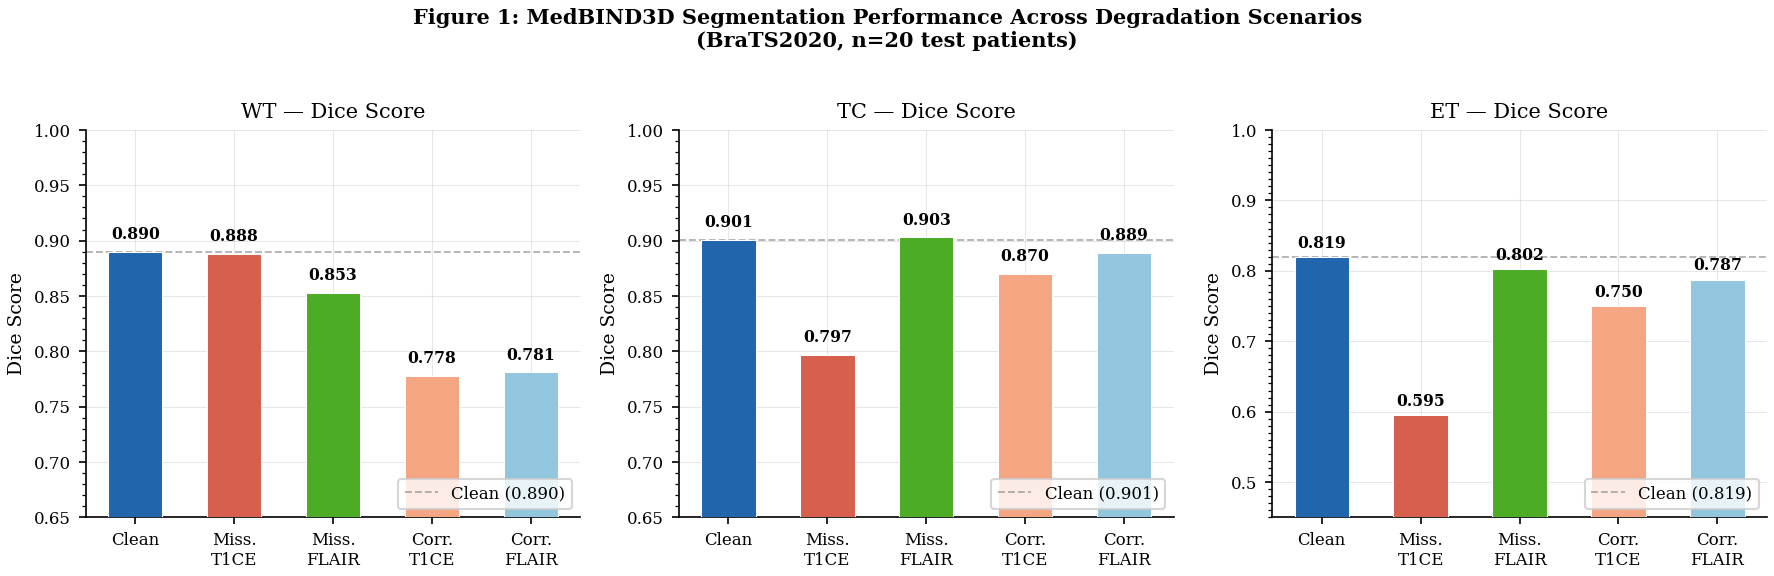

Figure 1 saved


In [15]:
# ── Figure Cell 2: Figure 1 — Main Results Across All Scenarios ───────────────
scenarios = ['Clean', 'Miss.\nT1CE', 'Miss.\nFLAIR', 'Corr.\nT1CE', 'Corr.\nFLAIR']
data = {
    'WT': [0.890, 0.888, 0.853, 0.778, 0.781],
    'TC': [0.901, 0.797, 0.903, 0.870, 0.889],
    'ET': [0.819, 0.595, 0.802, 0.750, 0.787],
}

fig, axes = plt.subplots(1, 3, figsize=(12, 3.8))
x = np.arange(len(scenarios)); width = 0.55

for ax, region in zip(axes, ['WT','TC','ET']):
    vals = data[region]
    bars = ax.bar(x, vals, width, color=SCENARIO_COLORS, edgecolor='white',
                  linewidth=0.5, zorder=3)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.008,
                f'{val:.3f}', ha='center', va='bottom', fontsize=7.5, fontweight='bold')
    ax.axhline(vals[0], color='gray', linestyle='--', linewidth=0.9,
               alpha=0.6, zorder=2, label=f'Clean ({vals[0]:.3f})')
    ax.set_xticks(x); ax.set_xticklabels(scenarios)
    ax.set_ylabel('Dice Score'); ax.set_title(f'{region} — Dice Score')
    ax.set_ylim(0.45 if region=='ET' else 0.65, 1.00)
    ax.yaxis.set_minor_locator(MultipleLocator(0.01))
    ax.legend(loc='lower right', framealpha=0.8)

plt.suptitle('Figure 1: MedBIND3D Segmentation Performance Across Degradation Scenarios\n'
             '(BraTS2020, n=20 test patients)', y=1.02, fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig1_main_results.png')
plt.show()
plt.close()
print('Figure 1 saved')

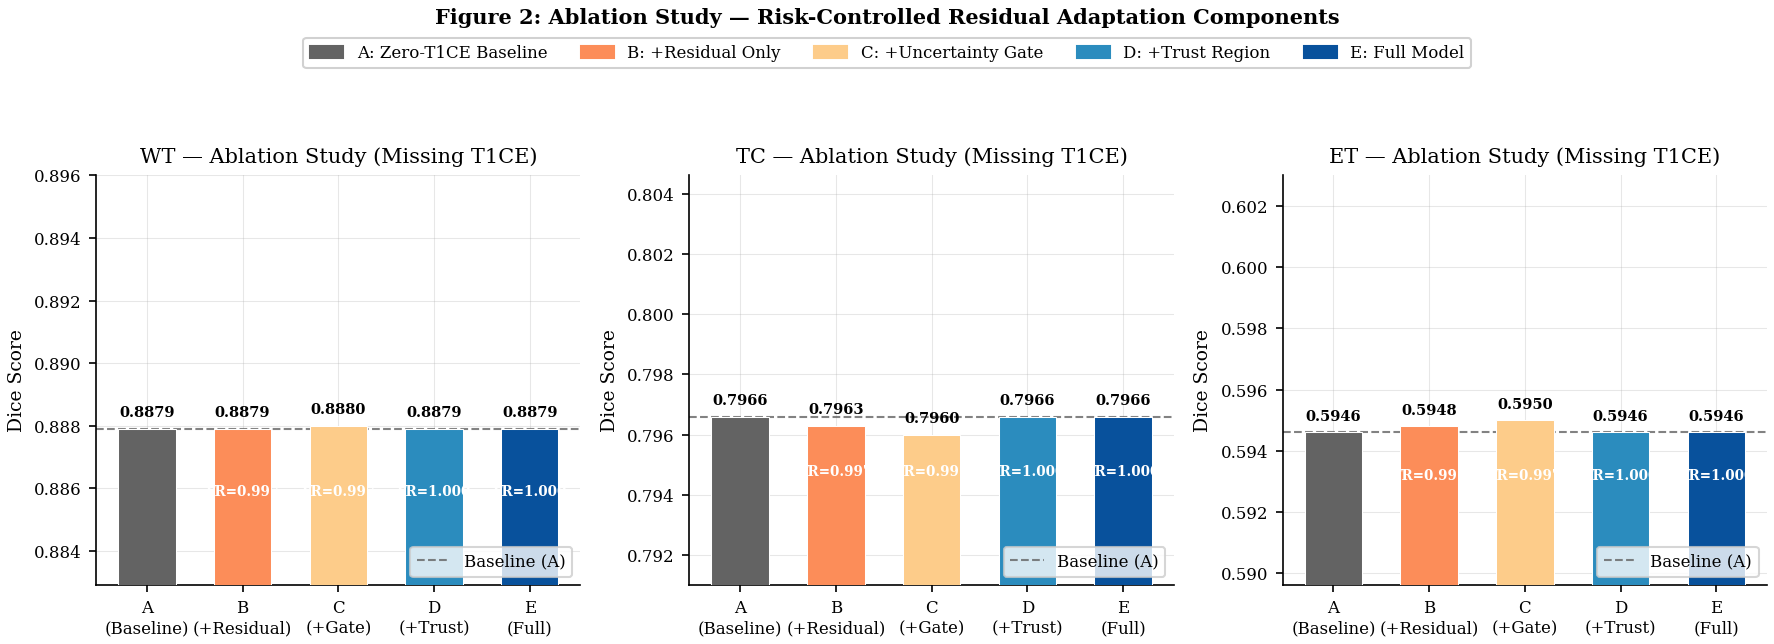

Figure 2 saved


In [16]:
# ── Figure Cell 3: Figure 2 — Ablation Study ──────────────────────────────────
abl_labels = ['A\n(Baseline)', 'B\n(+Residual)', 'C\n(+Gate)', 'D\n(+Trust)', 'E\n(Full)']
abl_data = {
    'WT': [0.8879, 0.8879, 0.8880, 0.8879, 0.8879],
    'TC': [0.7966, 0.7963, 0.7960, 0.7966, 0.7966],
    'ET': [0.5946, 0.5948, 0.5950, 0.5946, 0.5946],
}
fallback = [None, 0.997, 0.997, 1.000, 1.000]
abl_colors = ['#636363','#FC8D59','#FDCC8A','#2B8CBE','#08519C']

fig, axes = plt.subplots(1, 3, figsize=(12, 3.8))
for ax, region in zip(axes, ['WT','TC','ET']):
    vals = abl_data[region]
    bars = ax.bar(np.arange(5), vals, 0.6, color=abl_colors,
                  edgecolor='white', linewidth=0.5, zorder=3)
    ax.axhline(vals[0], color='#636363', linestyle='--', linewidth=1.0,
               alpha=0.8, zorder=2, label='Baseline (A)')
    for i, (bar, val) in enumerate(zip(bars, vals)):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.0003,
                f'{val:.4f}', ha='center', va='bottom', fontsize=7, fontweight='bold')
        if fallback[i] is not None:
            ax.text(bar.get_x()+bar.get_width()/2, vals[0]*0.998,
                    f'FR={fallback[i]:.3f}', ha='center', va='top',
                    fontsize=6.5, color='white', fontweight='bold')
    ax.set_xticks(np.arange(5)); ax.set_xticklabels(abl_labels)
    ax.set_ylabel('Dice Score'); ax.set_title(f'{region} — Ablation Study (Missing T1CE)')
    rng = max(vals)-min(vals)
    ax.set_ylim(min(vals)-max(rng*3,0.005), max(vals)+max(rng*3,0.008))
    ax.legend(loc='lower right', framealpha=0.8)

legend_patches = [mpatches.Patch(color=c, label=l) for c,l in zip(abl_colors, [
    'A: Zero-T1CE Baseline','B: +Residual Only','C: +Uncertainty Gate',
    'D: +Trust Region','E: Full Model'])]
fig.legend(handles=legend_patches, loc='upper center', ncol=5,
           bbox_to_anchor=(0.5,1.10), framealpha=0.9, fontsize=8)
plt.suptitle('Figure 2: Ablation Study — Risk-Controlled Residual Adaptation Components',
             y=1.14, fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig2_ablation.png')
plt.show()
plt.close()
print('Figure 2 saved')

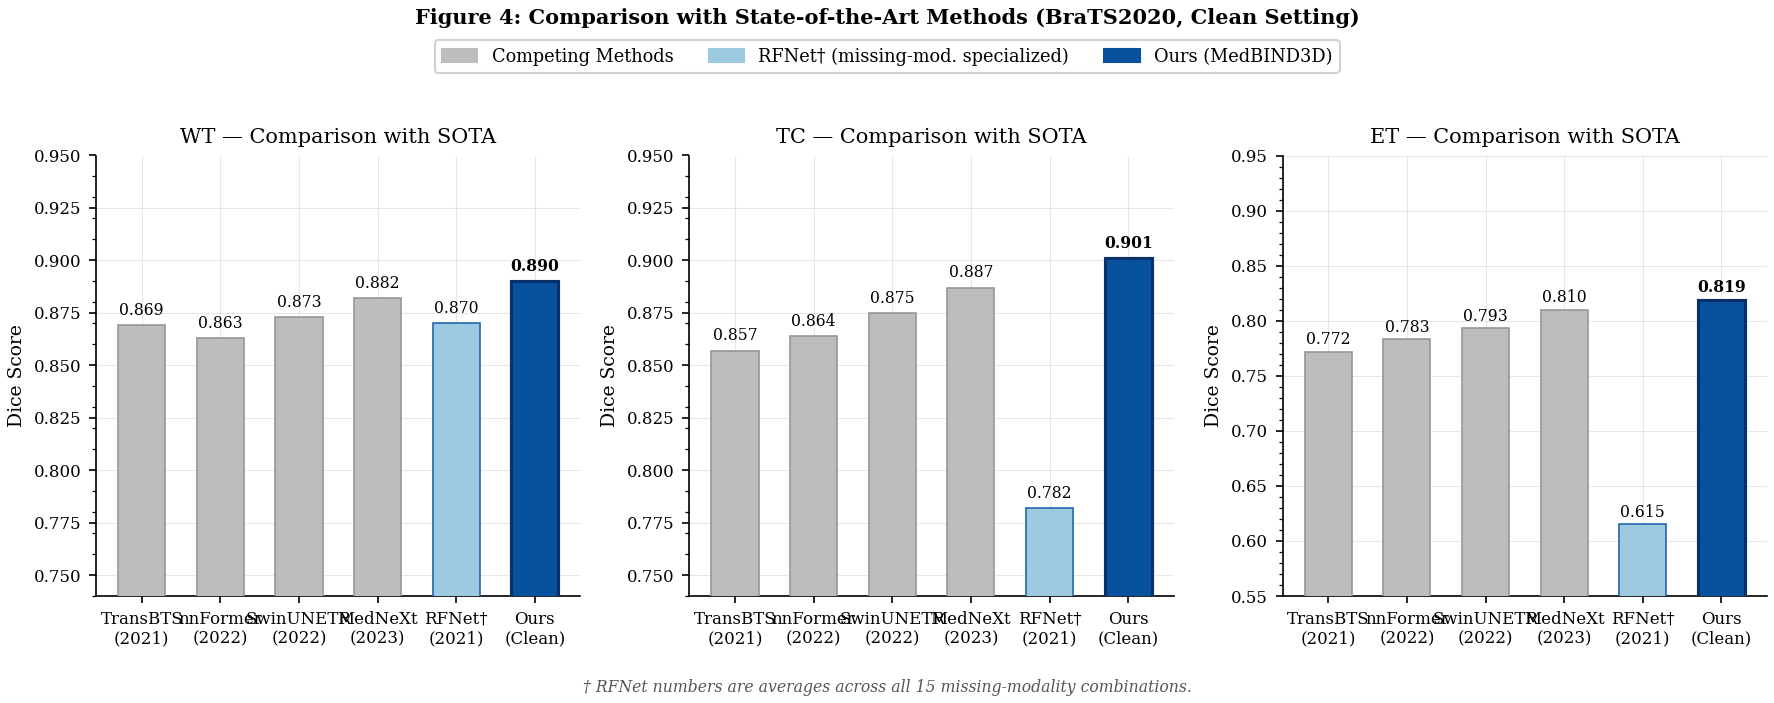

Figure 4 saved


In [18]:
# ── Figure Cell 5: Figure 4 — SOTA Comparison ─────────────────────────────────
methods = ['TransBTS\n(2021)','nnFormer\n(2022)','SwinUNETR\n(2022)',
           'MedNeXt\n(2023)','RFNet†\n(2021)','Ours\n(Clean)']
sota_data = {
    'WT': [0.869,0.863,0.873,0.882,0.870,0.890],
    'TC': [0.857,0.864,0.875,0.887,0.782,0.901],
    'ET': [0.772,0.783,0.793,0.810,0.615,0.819],
}
method_colors = ['#BDBDBD','#BDBDBD','#BDBDBD','#BDBDBD','#9ECAE1','#08519C']
method_edge   = ['#969696','#969696','#969696','#969696','#2166AC','#08306B']

fig, axes = plt.subplots(1,3,figsize=(12,4.0))
for ax,region in zip(axes,['WT','TC','ET']):
    vals = sota_data[region]
    bars = ax.bar(np.arange(len(methods)),vals,0.6,
                  color=method_colors,edgecolor=method_edge,linewidth=0.8,zorder=3)
    for bar,val in zip(bars,vals):
        ax.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.003,
                f'{val:.3f}',ha='center',va='bottom',fontsize=7.5,
                fontweight='bold' if val==max(vals) else 'normal')
    bars[-1].set_linewidth(1.5)
    ax.set_xticks(np.arange(len(methods))); ax.set_xticklabels(methods)
    ax.set_ylabel('Dice Score'); ax.set_title(f'{region} — Comparison with SOTA')
    ax.set_ylim(0.55 if region=='ET' else 0.74,0.95)
    ax.yaxis.set_minor_locator(MultipleLocator(0.01))

legend_patches=[
    mpatches.Patch(color='#BDBDBD',edgecolor='#969696',label='Competing Methods'),
    mpatches.Patch(color='#9ECAE1',edgecolor='#2166AC',label='RFNet† (missing-mod. specialized)'),
    mpatches.Patch(color='#08519C',edgecolor='#08306B',label='Ours (MedBIND3D)'),
]
fig.legend(handles=legend_patches,loc='upper center',ncol=3,
           bbox_to_anchor=(0.5,1.06),framealpha=0.9,fontsize=8.5)
fig.text(0.5,-0.04,'† RFNet numbers are averages across all 15 missing-modality combinations.',
         ha='center',fontsize=7.5,style='italic',color='#555555')
plt.suptitle('Figure 4: Comparison with State-of-the-Art Methods (BraTS2020, Clean Setting)',
             y=1.10,fontsize=10,fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig4_sota_comparison.png')
plt.show()
plt.close()
print('Figure 4 saved')

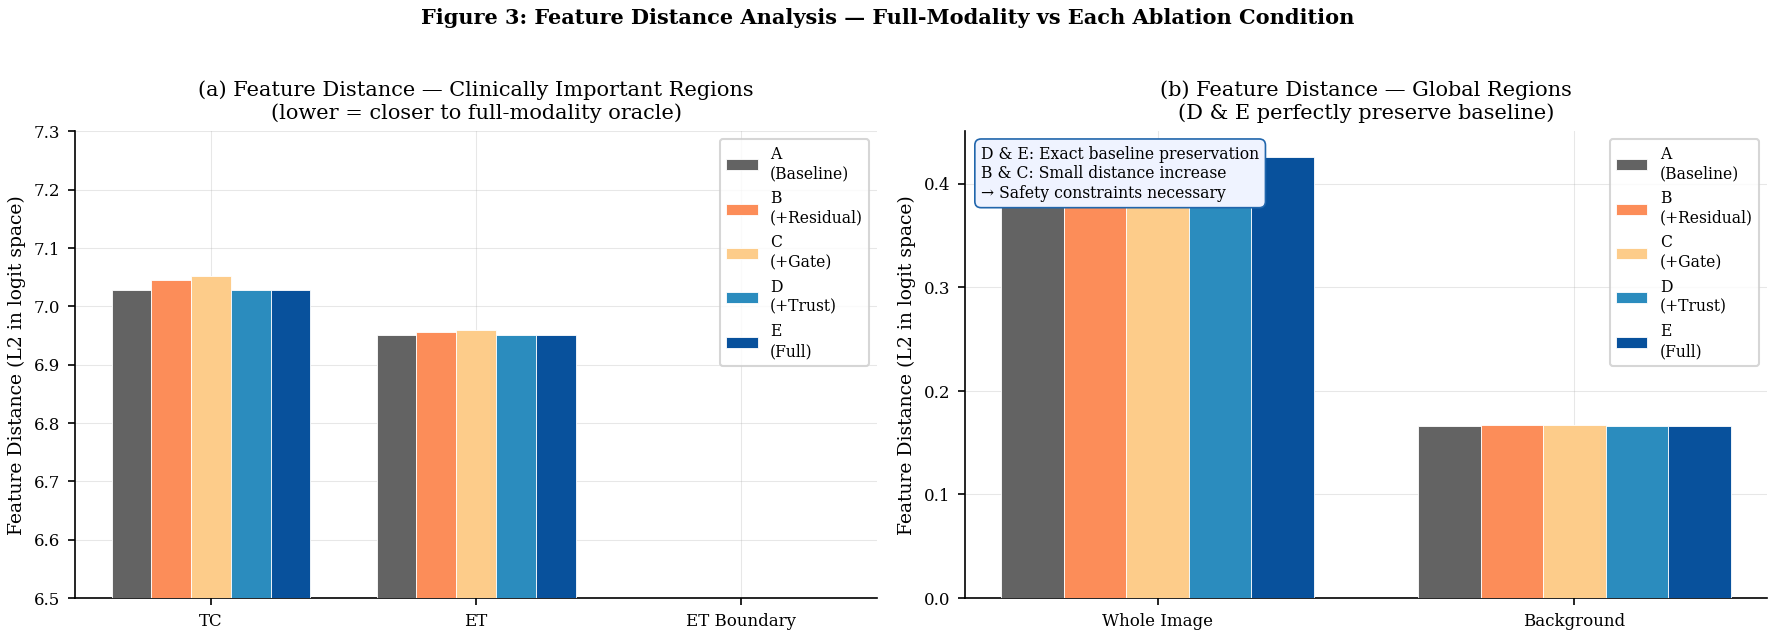

Figure 3 saved


In [17]:
# ── Figure Cell 4: Figure 3 — Feature Distance Analysis ───────────────────────
feat_data = {
    'A\n(Baseline)':  [0.4259,4.4337,7.0277,6.9502,6.0200,0.1657],
    'B\n(+Residual)': [0.4280,4.4556,7.0445,6.9552,6.0734,0.1665],
    'C\n(+Gate)':     [0.4291,4.4665,7.0522,6.9599,6.0966,0.1669],
    'D\n(+Trust)':    [0.4259,4.4337,7.0277,6.9502,6.0200,0.1657],
    'E\n(Full)':      [0.4259,4.4337,7.0277,6.9502,6.0200,0.1657],
}
fd_colors = ['#636363','#FC8D59','#FDCC8A','#2B8CBE','#08519C']
width = 0.15

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

ax = axes[0]
x = np.arange(3)
for i,(lbl,vals) in enumerate(feat_data.items()):
    ax.bar(x+i*width-2*width,[vals[j] for j in [2,3,4]],width,
           color=fd_colors[i],label=lbl,edgecolor='white',linewidth=0.4,zorder=3)
ax.set_xticks(x); ax.set_xticklabels(['TC','ET','ET Boundary'])
ax.set_ylabel('Feature Distance (L2 in logit space)')
ax.set_title('(a) Feature Distance — Clinically Important Regions\n(lower = closer to full-modality oracle)')
ax.legend(loc='upper right',framealpha=0.8,fontsize=7.5)
ax.set_ylim(6.5,7.3)

ax = axes[1]
x = np.arange(2)
for i,(lbl,vals) in enumerate(feat_data.items()):
    ax.bar(x+i*width-2*width,[vals[j] for j in [0,5]],width,
           color=fd_colors[i],label=lbl,edgecolor='white',linewidth=0.4,zorder=3)
ax.set_xticks(x); ax.set_xticklabels(['Whole Image','Background'])
ax.set_ylabel('Feature Distance (L2 in logit space)')
ax.set_title('(b) Feature Distance — Global Regions\n(D & E perfectly preserve baseline)')
ax.legend(loc='upper right',framealpha=0.8,fontsize=7.5)
ax.text(0.02,0.97,'D & E: Exact baseline preservation\nB & C: Small distance increase\n→ Safety constraints necessary',
        transform=ax.transAxes,fontsize=7.5,va='top',
        bbox=dict(boxstyle='round,pad=0.4',facecolor='#EFF3FF',edgecolor='#2166AC',linewidth=0.8))

plt.suptitle('Figure 3: Feature Distance Analysis — Full-Modality vs Each Ablation Condition',
             y=1.02,fontsize=10,fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig3_feature_distance.png')
plt.show()
plt.close()
print('Figure 3 saved')

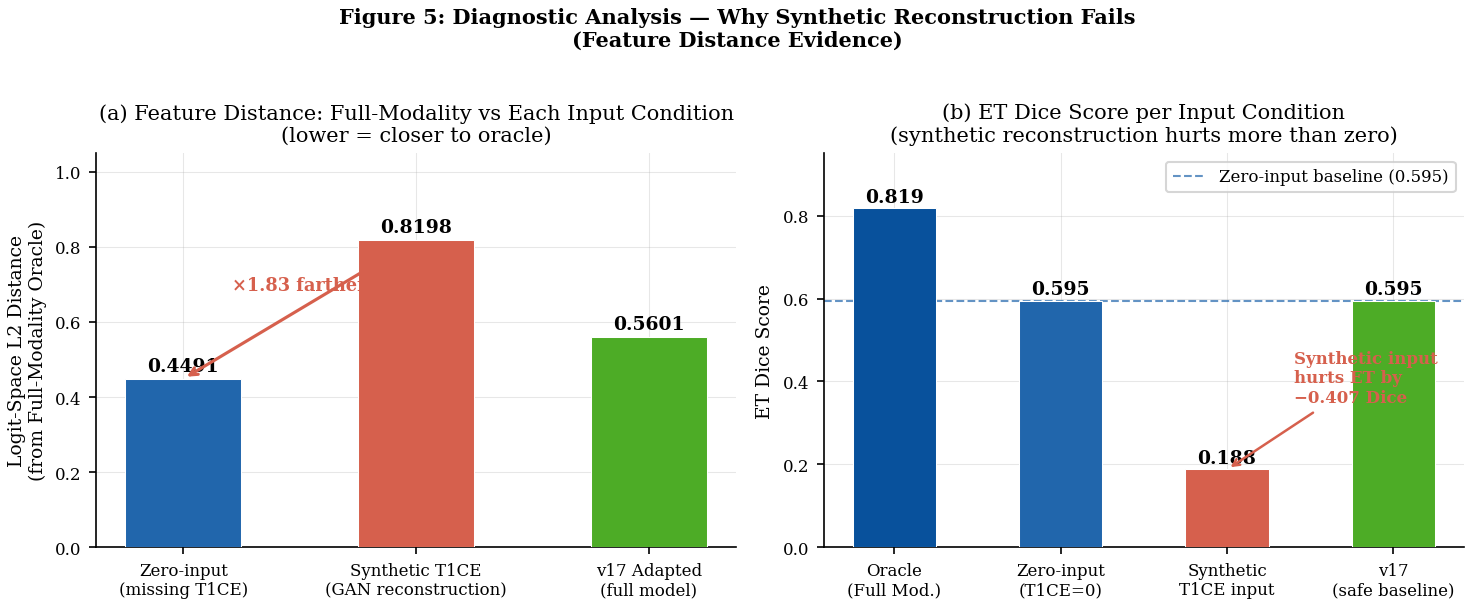

Figure 5 saved — KEY diagnostic figure for the paper


In [19]:
# ── Figure Cell 6: Figure 5 — Diagnostic Analysis (Key Figure) ────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4.0))

ax = axes[0]
conditions=['Zero-input\n(missing T1CE)','Synthetic T1CE\n(GAN reconstruction)','v17 Adapted\n(full model)']
distances=[0.4491,0.8198,0.5601]
bar_colors=['#2166AC','#D6604D','#4DAC26']
bars=ax.bar(conditions,distances,0.5,color=bar_colors,edgecolor='white',linewidth=0.5,zorder=3)
for bar,val in zip(bars,distances):
    ax.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.01,
            f'{val:.4f}',ha='center',va='bottom',fontsize=9,fontweight='bold')
ax.annotate('',xy=(1,distances[1]),xytext=(0,distances[0]),
            arrowprops=dict(arrowstyle='<->',color='#D6604D',lw=1.5))
ax.text(0.5,(distances[0]+distances[1])/2+0.05,
        f'×{distances[1]/distances[0]:.2f} farther',
        ha='center',fontsize=8.5,color='#D6604D',fontweight='bold')
ax.set_ylabel('Logit-Space L2 Distance\n(from Full-Modality Oracle)')
ax.set_title('(a) Feature Distance: Full-Modality vs Each Input Condition\n(lower = closer to oracle)')
ax.set_ylim(0,1.05)

ax = axes[1]
et_dice=[0.8188,0.5946,0.1878,0.5946]
cond_labels=['Oracle\n(Full Mod.)','Zero-input\n(T1CE=0)','Synthetic\nT1CE input','v17\n(safe baseline)']
bar_colors2=['#08519C','#2166AC','#D6604D','#4DAC26']
bars2=ax.bar(cond_labels,et_dice,0.5,color=bar_colors2,edgecolor='white',linewidth=0.5,zorder=3)
for bar,val in zip(bars2,et_dice):
    ax.text(bar.get_x()+bar.get_width()/2,val+0.005,
            f'{val:.3f}',ha='center',va='bottom',fontsize=9,fontweight='bold')
ax.axhline(et_dice[1],color='#2166AC',linestyle='--',linewidth=1.0,alpha=0.7,
           label=f'Zero-input baseline ({et_dice[1]:.3f})')
ax.set_ylabel('ET Dice Score')
ax.set_title('(b) ET Dice Score per Input Condition\n(synthetic reconstruction hurts more than zero)')
ax.set_ylim(0,0.95); ax.legend(loc='upper right',framealpha=0.8)
ax.annotate('Synthetic input\nhurts ET by\n−0.407 Dice',
            xy=(2,et_dice[2]),xytext=(2.4,0.35),
            arrowprops=dict(arrowstyle='->',color='#D6604D',lw=1.2),
            fontsize=8,color='#D6604D',fontweight='bold')

plt.suptitle('Figure 5: Diagnostic Analysis — Why Synthetic Reconstruction Fails\n(Feature Distance Evidence)',
             y=1.02,fontsize=10,fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig5_diagnostic.png')
plt.show()
plt.close()
print('Figure 5 saved — KEY diagnostic figure for the paper')

In [ ]:
# ── Figure Cell 7: Figure 6 — Comprehensive Summary ───────────────────────────
fig = plt.figure(figsize=(14, 8))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

data={'WT':[0.890,0.888,0.853,0.778,0.781],
      'TC':[0.901,0.797,0.903,0.870,0.889],
      'ET':[0.819,0.595,0.802,0.750,0.787]}
abl_colors=['#636363','#FC8D59','#FDCC8A','#2B8CBE','#08519C']

for col,region in enumerate(['WT','TC','ET']):
    ax=fig.add_subplot(gs[0,col])
    vals=data[region]
    ax.bar(np.arange(5),vals,0.6,color=SCENARIO_COLORS,edgecolor='white',linewidth=0.5,zorder=3)
    for i,val in enumerate(vals):
        ax.text(i,val+0.004,f'{val:.3f}',ha='center',va='bottom',fontsize=7)
    ax.axhline(vals[0],color='gray',linestyle='--',lw=0.9,alpha=0.6)
    ax.set_xticks(np.arange(5))
    ax.set_xticklabels(['Clean','Miss\nT1CE','Miss\nFLAIR','Corr\nT1CE','Corr\nFLAIR'],fontsize=7)
    ax.set_ylabel('Dice'); ax.set_title(f'{region} Region',fontweight='bold')
    ax.set_ylim(max(0.4,min(vals)-0.05),1.02)

ax=fig.add_subplot(gs[1,0])
methods_s=['TransBTS','nnFormer','SwinUNETR','MedNeXt','RFNet†','Ours']
et_sota=[0.772,0.783,0.793,0.810,0.615,0.819]
bc=['#BDBDBD']*4+['#9ECAE1','#08519C']
bars=ax.barh(methods_s,et_sota,0.6,color=bc,edgecolor='white',lw=0.5,zorder=3)
for bar,val in zip(bars,et_sota):
    ax.text(val+0.002,bar.get_y()+bar.get_height()/2,f'{val:.3f}',
            va='center',fontsize=7.5,fontweight='bold' if val==max(et_sota) else 'normal')
ax.set_xlabel('ET Dice Score'); ax.set_title('SOTA Comparison (ET)',fontweight='bold')
ax.set_xlim(0.55,0.88); ax.invert_yaxis()

ax=fig.add_subplot(gs[1,1])
cond_s=['Zero-input','Synthetic\nT1CE','v17\nAdapter']
dists=[0.4491,0.8198,0.5601]
bc2=['#2166AC','#D6604D','#4DAC26']
ax.bar(cond_s,dists,0.5,color=bc2,edgecolor='white',lw=0.5,zorder=3)
for i,val in enumerate(dists):
    ax.text(i,val+0.01,f'{val:.3f}',ha='center',va='bottom',fontsize=8,fontweight='bold')
ax.set_ylabel('L2 Distance from Oracle')
ax.set_title('Feature Distance Diagnostic',fontweight='bold')
ax.set_ylim(0,1.0)
ax.text(0.5,0.92,'↑ Synthetic T1CE is\n1.8× farther than zero',
        transform=ax.transAxes,ha='center',fontsize=7.5,
        bbox=dict(boxstyle='round',facecolor='#FFF3CD',edgecolor='#D6604D',lw=0.8))

ax=fig.add_subplot(gs[1,2])
et_abl=[0.5946,0.5948,0.5950,0.5946,0.5946]
fr_vals=[0,0.997,0.997,1.000,1.000]
ax.bar(np.arange(5),et_abl,0.6,color=abl_colors,edgecolor='white',lw=0.5,zorder=3)
ax2b=ax.twinx()
ax2b.plot(np.arange(5),fr_vals,'k--o',markersize=4,linewidth=1.2,label='Fallback Rate',zorder=5)
ax2b.set_ylabel('Fallback Rate',fontsize=8); ax2b.set_ylim(-0.05,1.15)
for i,val in enumerate(et_abl):
    ax.text(i,val+0.0002,f'{val:.4f}',ha='center',va='bottom',fontsize=6.5,fontweight='bold')
ax.set_xticks(np.arange(5)); ax.set_xticklabels(['A','B','C','D','E'],fontsize=8)
ax.set_ylabel('ET Dice'); ax.set_title('Ablation Safety (ET)',fontweight='bold')
ax.set_ylim(0.590,0.600); ax2b.legend(loc='lower right',fontsize=7)

scenario_patches=[mpatches.Patch(color=c,label=l) for c,l in zip(SCENARIO_COLORS,
    ['Clean','Missing T1CE','Missing FLAIR','Corrupt T1CE','Corrupt FLAIR'])]
fig.legend(handles=scenario_patches,loc='upper center',ncol=5,
           bbox_to_anchor=(0.5,1.02),fontsize=8,framealpha=0.9)
fig.suptitle('MedBIND3D: Reliability-Aware Test-Time Adaptation for Brain Tumor Segmentation\n'
             'Comprehensive Results Summary (BraTS2020, n=20 test patients)',
             y=1.06,fontsize=11,fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig6_summary.png')
plt.show()
plt.close()
print('Figure 6 saved')